##1.Import Libraries & Preprocessing Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score , confusion_matrix, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import pickle

In [ ]:
df=pd.read_csv('sms.csv',sep='\t',names=['Status','Message'])


In [ ]:
df.head()


,Status,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
len(df)


5572

In [ ]:
len(df[df.Status=='spam'])


747

In [ ]:
len(df[df.Status=='ham'])


4825

In [ ]:
df.loc[df["Status"]=='ham',"Status",]=1


In [ ]:
df.loc[df["Status"]=='spam',"Status",]=0


In [ ]:
df.head()


,Status,Message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df_x=df["Message"]
df_y=df["Status"]

In [ ]:
cv = TfidfVectorizer(min_df=1,stop_words='english')


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=4)


In [ ]:
len(x_test)

1115

In [ ]:
x_train.head()


,Message
1457,U sleeping now.. Or you going to take? Haha.. ...
472,"How long has it been since you screamed, princ..."
2481,Urgent! call 09066612661 from landline. Your c...
243,"Okay. No no, just shining on. That was meant t..."
1413,"Wen ur lovable bcums angry wid u, dnt take it ..."


In [ ]:
x_traincv=cv.fit_transform(x_train)
x_traincv.toarray()



array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.19618715, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
x_traincv.shape

(4457, 7498)

In [ ]:
x_testcv=cv.transform(x_test)
x_testcv.toarray()


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
x_testcv.shape

(1115, 7498)

##2.Modeling & Evaluation

In [ ]:
 mnb = MultinomialNB()


In [ ]:
y_train=y_train.astype('int')
y_train


,Status
1457,1
472,1
2481,0
243,1
1413,1
...,...
3671,1
709,0
2487,1
174,1


In [ ]:
mnb.fit(x_traincv,y_train)


MultinomialNB()

In [ ]:
predictions=mnb.predict(x_testcv)
predictions

array([1, 1, 1, ..., 1, 1, 0])

In [ ]:
true_labels=np.array(y_test)
true_labels

array([1, 1, 1, ..., 1, 1, 0], dtype=object)

In [ ]:
count=0
for i in range (len(predictions)):
    if predictions[i]==true_labels[i]:
        count=count+1

In [ ]:
count


1068

In [ ]:
len(predictions)


1115

In [ ]:
y_test = y_test.astype('int')
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9578


In [ ]:
# Ensure y_test is integer type for metric calculations
y_test_int = y_test.astype('int')

# Calculate Confusion Matrix
cm = confusion_matrix(y_test_int, predictions)
print("\nConfusion Matrix:\n", cm)

# Calculate Precision, Recall, F1-Score
precision = precision_score(y_test_int, predictions)
recall = recall_score(y_test_int, predictions)
f1 = f1_score(y_test_int, predictions)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Confusion Matrix:
 [[122  46]
 [  1 946]]

Precision: 0.9536
Recall: 0.9989
F1-Score: 0.9758


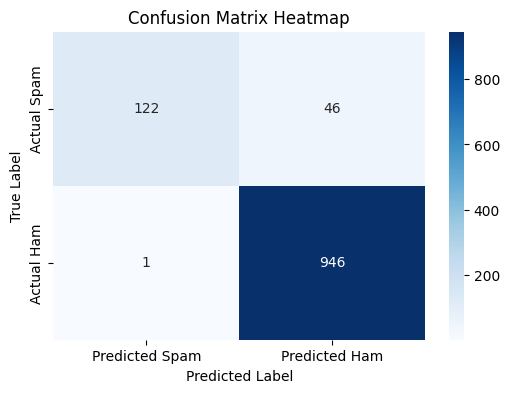

In [ ]:
# Assuming 'cm' (confusion matrix) is already calculated
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Spam', 'Predicted Ham'], yticklabels=['Actual Spam', 'Actual Ham'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42) # 'liblinear' is good for small datasets and handles L1/L2 regularization
log_reg.fit(x_traincv, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
print(x_traincv.shape)
print(log_reg.n_features_in_)

(4457, 7498)
7498


In [ ]:
# Make predictions on the test set
log_reg_predictions = log_reg.predict(x_testcv)

# Calculate evaluation metrics
log_reg_accuracy = accuracy_score(y_test_int, log_reg_predictions)
log_reg_cm = confusion_matrix(y_test_int, log_reg_predictions)
log_reg_precision = precision_score(y_test_int, log_reg_predictions)
log_reg_recall = recall_score(y_test_int, log_reg_predictions)
log_reg_f1 = f1_score(y_test_int, log_reg_predictions)

print(f"\nLogistic Regression Model Accuracy: {log_reg_accuracy:.4f}")
print("\nLogistic Regression Confusion Matrix:\n", log_reg_cm)
print(f"\nLogistic Regression Precision: {log_reg_precision:.4f}")
print(f"Logistic Regression Recall: {log_reg_recall:.4f}")
print(f"Logistic Regression F1-Score: {log_reg_f1:.4f}")


Logistic Regression Model Accuracy: 0.9507

Logistic Regression Confusion Matrix:
 [[113  55]
 [  0 947]]

Logistic Regression Precision: 0.9451
Logistic Regression Recall: 1.0000
Logistic Regression F1-Score: 0.9718


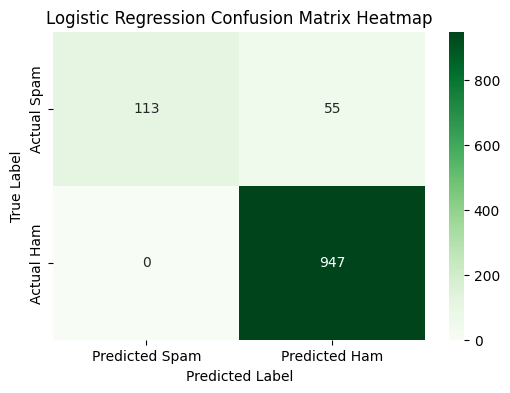

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Predicted Spam', 'Predicted Ham'], yticklabels=['Actual Spam', 'Actual Ham'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix Heatmap')
plt.show()

##3.Prepare For Deployments

In [ ]:
# Save the Logistic Regression model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(log_reg, file)

print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

Logistic Regression model saved as 'logistic_regression_model.pkl'


In [ ]:
# Save the TfidfVectorizer
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(cv, file)

print("TfidfVectorizer saved as 'tfidf_vectorizer.pkl'")


TfidfVectorizer saved as 'tfidf_vectorizer.pkl'


In [ ]:
import pkg_resources

# List of packages identified from the imports in the notebook
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn" # sklearn is scikit-learn for pip
]

# Get the versions of the installed packages
installed_packages = pkg_resources.working_set
package_list = sorted([f"{i.key}=={i.version}" for i in installed_packages if i.key in packages])

# Write to requirements.txt
with open('requirements.txt', 'w') as f:
    for p in package_list:
        f.write(p + '\n')

print("requirements.txt has been generated with the following packages:")
for p in package_list:
    print(p)

/tmp/ipykernel_909/3988701533.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


requirements.txt has been generated with the following packages:
matplotlib==3.10.0
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
seaborn==0.13.2
